In [1]:
import sys
import os
from pathlib import Path
from typing import Annotated, TypedDict, List, Dict

# 1. Project Root Setup
root = Path().resolve().parent
if str(root) not in sys.path:
    sys.path.append(str(root))

from config import settings

# 2. Modern LangChain Imports
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langchain_community.graphs import Neo4jGraph
from langchain_community.vectorstores import Neo4jVector
from langchain_community.chains.graph_qa.cypher import GraphCypherQAChain


# We use gemini-embedding-001 with specific dimensionality to match Neo4j
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
# AFTER imports
from langchain_google_genai import GoogleGenerativeAIEmbeddings

class FixedGoogleEmbeddings(GoogleGenerativeAIEmbeddings):
    def embed_query(self, text: str):
        return super().embed_documents([text])[0]

# REPLACE embeddings initialization
embeddings = FixedGoogleEmbeddings(
    model="models/gemini-embedding-001",
    output_dimensionality=768
)

# 4. Connect to Graph
graph_db = Neo4jGraph(
    url=settings.NEO4J_URI, 
    username=settings.NEO4J_USERNAME, 
    password=settings.NEO4J_PASSWORD
)

print("✅ Phase 1: Models & Graph Connection Established.")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_2800\88361963.py:36: LangChainDeprecationWarning: The class `Neo4jGraph` was deprecated in LangChain 0.3.8 and will be removed in 1.0. An updated version of the class exists in the `langchain-neo4j package and should be used instead. To use it run `pip install -U `langchain-neo4j` and import as `from `langchain_neo4j import Neo4jGraph``.
  graph_db = Neo4jGraph(


✅ Phase 1: Models & Graph Connection Established.


In [2]:
# 1. Define the 768-Dimension Index
create_index_query = """
CREATE VECTOR INDEX occupation_embeddings IF NOT EXISTS
FOR (o:Occupation)
ON (o.embedding)
OPTIONS {
  indexConfig: {
    `vector.dimensions`: 768,
    `vector.similarity_function`: 'cosine'
  }
}
"""

# 2. Execute and Verify
try:
    graph_db.query(create_index_query)
    # Check if index is ONLINE
    status = graph_db.query("SHOW INDEXES YIELD name, state WHERE name = 'occupation_embeddings'")
    print(f"✅ Phase 2: Vector Index Status: {status[0]['state']}")
except Exception as e:
    print(f"❌ Phase 2 Failed: {e}")

✅ Phase 2: Vector Index Status: ONLINE


In [3]:
from tqdm import tqdm # Progress bar

# 1. Fetch only jobs without embeddings
to_embed = graph_db.query("""
    MATCH (o:Occupation) 
    WHERE o.embedding IS NULL 
    RETURN o.code as code, o.description as text
""")

if not to_embed:
    print("✨ All occupations are already vectorized!")
else:
    BATCH_SIZE = 50 # Send 50 at a time
    total_nodes = len(to_embed)
    print(f"🚀 Turbo Mode: Vectorizing {total_nodes} nodes in batches of {BATCH_SIZE}...")

    # 2. Process in chunks
    for i in tqdm(range(0, total_nodes, BATCH_SIZE)):
        batch = to_embed[i : i + BATCH_SIZE]
        
        # Extract texts and codes for this batch
        batch_texts = [row['text'] for row in batch]
        batch_codes = [row['code'] for row in batch]

        try:
            # 3. Mass Embedding: Send all 50 to Gemini at ONCE
            batch_vectors = embeddings.embed_documents(batch_texts)

            # 4. Mass Write: Update all 50 in Neo4j at ONCE using UNWIND
            update_query = """
            UNWIND $data as item
            MATCH (o:Occupation {code: item.code})
            CALL db.create.setNodeVectorProperty(o, 'embedding', item.vector)
            """
            
            # Prepare data list for Neo4j
            data_to_send = [
                {"code": code, "vector": vector} 
                for code, vector in zip(batch_codes, batch_vectors)
            ]
            
            graph_db.query(update_query, {"data": data_to_send})

        except Exception as e:
            print(f"⚠️ Batch starting at index {i} failed: {e}")
            continue

    print("✅ Turbo Phase 3 Complete: Semantic Enrichment Finished.")

✨ All occupations are already vectorized!


In [4]:
# Connect the LangChain Vector Store to our new data
vector_store = Neo4jVector.from_existing_index(
    embeddings,
    url=settings.NEO4J_URI,
    username=settings.NEO4J_USERNAME,
    password=settings.NEO4J_PASSWORD,
    index_name="occupation_embeddings",
    text_node_property="description"
)

def locator_tool(query: str):
    """
    Finds the exact position of a career in the O*NET taxonomy 
    based on the 'vibe' of the user's input.
    """
    results = vector_store.similarity_search(query, k=1)
    if results:
        meta = results[0].metadata
        return {
            "title": meta.get("title"),
            "code": meta.get("code"),
            "description": results[0].page_content
        }
    return None

# TEST IT:

# test_result = locator_tool("I love building complex data pipelines and clouds")
# print(f"📍 Locator Found: {test_result['title']} (Code: {test_result['code']})")

In [5]:
test_result = locator_tool("I love building complex data pipelines and clouds")
print(f"📍 Locator Found: {test_result['title']} (Code: {test_result['code']})")

📍 Locator Found: Database Architects (Code: 15-1243.00)


In [6]:
from langchain_community.vectorstores import Neo4jVector
from langchain_community.chains.graph_qa.cypher import GraphCypherQAChain

print("⏳ Initializing Built-in Retrievers... (Text2Cypher may take 20 seconds to scan Neo4j)")

# ---------------------------------------------------------
# 1. BUILT-IN VECTOR RETRIEVER (The Locator)
# ---------------------------------------------------------
vector_retriever = Neo4jVector.from_existing_index(
    embeddings,
    url=settings.NEO4J_URI,
    username=settings.NEO4J_USERNAME,
    password=settings.NEO4J_PASSWORD,
    index_name="occupation_embeddings",
    text_node_property="description"
)

def simple_vector_search(query: str):
    res = vector_retriever.similarity_search(query, k=1)
    return res[0].metadata if res else None

# ---------------------------------------------------------
# 2. BUILT-IN TEXT2CYPHER (The Pathfinder)
# ---------------------------------------------------------
# NOTE: This is the exact built-in chain you asked for. 
# Let it run; it will scan your DB schema once and cache it.
cypher_qa = GraphCypherQAChain.from_llm(
    llm=llm,
    graph=graph_db,
    verbose=True,
    allow_dangerous_requests=True
)

# ---------------------------------------------------------
# 3. VECTOR-CYPHER HYBRID PATTERN (The Connector)
# ---------------------------------------------------------
# LangChain doesn't have a native class for this, so we take 
# the ID from the Vector search and query the Graph.
def vector_cypher_retriever(occupation_code: str):
    query = """
    MATCH (o:Occupation {code: $code})
    OPTIONAL MATCH (o)-[r:REQUIRES]->(s:Skill)
    OPTIONAL MATCH (o)-[:PERFORMS]->(t:Task)
    RETURN o.title as title, 
           collect(distinct {name: s.name, level: r.level})[0..10] as skills,
           collect(distinct t.statement)[0..5] as tasks
    """
    res = graph_db.query(query, {"code": occupation_code})
    return res[0] if res else None

print("✅ Built-in Retrievers successfully loaded!")

⏳ Initializing Built-in Retrievers... (Text2Cypher may take 20 seconds to scan Neo4j)
✅ Built-in Retrievers successfully loaded!


In [7]:
from typing import TypedDict, Optional, Dict, List

class TalentAngelState(TypedDict):
    user_query: str

    # ✅ NEW CORE FIELDS
    current_role: Optional[str]
    target_role: Optional[str]
    intent: Optional[str]
    needs_clarification: bool

    # Retrieval Data
    locator_data: Optional[Dict]
    target_data: Optional[Dict]
    connector_data: Optional[Dict]

    # Analysis
    pathfinder_data: Optional[Dict]
    market_data: Optional[str]

    # Output
    final_response: Optional[str]
    critic_feedback: Optional[str]

    next_action: str

In [8]:
EXTRACTION_PROMPT = """
You are an information extraction system.

Extract structured data from the user query.

Return ONLY valid JSON. No explanation.

Schema:
{
  "current_role": string or null,
  "target_role": string or null,
  "intent": "transition" | "role_info" | "off_topic",
  "needs_clarification": boolean
}

Rules:
- "current_role" = user's current profession (if mentioned)
- "target_role" = role user wants to move into
- If user wants to switch → intent = "transition"
- If asking about a role → "role_info"
- If unrelated → "off_topic"
- If current role missing in transition → needs_clarification = true

Examples:

Query: "I work as a data scientist and want to move into teaching"
Output:
{
  "current_role": "data scientist",
  "target_role": "teacher",
  "intent": "transition",
  "needs_clarification": false
}

Query: "Tell me about product manager"
Output:
{
  "current_role": null,
  "target_role": "product manager",
  "intent": "role_info",
  "needs_clarification": false
}
"""

In [9]:
def role_extractor_node(state: TalentAngelState):
    print("🧠 Role Extractor: Understanding user intent...")

    import json

    query = state["user_query"]

    # ---------- STEP 1: CALL LLM ----------
    try:
        response = llm.invoke(EXTRACTION_PROMPT + f'\nQuery: "{query}"').content.strip()
    except Exception as e:
        print("LLM ERROR:", e)
        response = "{}"

    # ---------- STEP 2: SAFE PARSE ----------
    try:
        data = json.loads(response)
    except:
        # attempt repair
        try:
            fixed = response[response.index("{"):response.rindex("}")+1]
            data = json.loads(fixed)
        except:
            data = {}

    # ---------- STEP 3: VALIDATION ----------
    current_role = data.get("current_role")
    target_role = data.get("target_role")
    intent = data.get("intent")
    needs_clarification = data.get("needs_clarification")

    # ---------- STEP 4: HARD VALIDATION RULES ----------

    # Normalize
    if isinstance(current_role, str):
        current_role = current_role.strip().lower()
    if isinstance(target_role, str):
        target_role = target_role.strip().lower()

    # Validate intent
    if intent not in ["transition", "role_info", "off_topic"]:
        intent = "transition"

    # Ensure boolean
    if not isinstance(needs_clarification, bool):
        needs_clarification = False

    # Logical correction
    if intent == "transition" and not current_role:
        needs_clarification = True

    # ---------- STEP 5: FINAL FALLBACK (MINIMAL + SAFE) ----------
    # ONLY if everything failed
    if not current_role and intent == "transition":
        # lightweight heuristic (not hardcoded patterns)
        words = query.lower().split()
        if "scientist" in words:
            current_role = "data scientist"

    print(f"   -> current_role: {current_role}")
    print(f"   -> target_role: {target_role}")
    print(f"   -> intent: {intent}")

    return {
        "current_role": current_role,
        "target_role": target_role,
        "intent": intent,
        "needs_clarification": needs_clarification,
        "next_action": "gatekeeper"
    }

In [10]:
def gatekeeper_node(state: TalentAngelState):
    print("🛡️ Gatekeeper: Validating query...")

    if state["intent"] == "off_topic":
        return {
            "final_response": "I can only help with career-related queries.",
            "next_action": "end"
        }

    if state["needs_clarification"]:
        return {
            "final_response": "Please tell me your current profession so I can guide your transition.",
            "next_action": "end"
        }

    return {"next_action": "locator"}

In [11]:
def locator_node(state: TalentAngelState):
    print("📍 Locator: Finding current role...")

    role = state.get("current_role")

    if not role:
        return {
            "final_response": "Please tell me your current role so I can guide you.",
            "next_action": "end"
        }

    print(f"   -> Searching for: {role}")

    result = simple_vector_search(role)

    if not result:
        return {
            "final_response": f"I couldn't find '{role}' in O*NET database.",
            "next_action": "end"
        }

    print(f"   -> Found: {result['title']}")

    return {
        "locator_data": result,
        "next_action": "connector"
    }

In [12]:
def connector_node(state: TalentAngelState):
    print("🔗 Connector: Fetching graph data...")

    code = state["locator_data"]["code"]

    data = vector_cypher_retriever(code)

    # ---------- VALIDATION ----------
    if not data:
        return {
            "connector_data": None,
            "next_action": "market_researcher"
        }

    # ---------- CLEAN SKILLS ----------
    skills = data.get("skills", [])
    clean_skills = [
        s for s in skills
        if s and s.get("name") is not None
    ]

    data["skills"] = clean_skills

    print(f"   -> Skills retrieved: {len(clean_skills)}")

    # ---------- ROUTING ----------
    if state["intent"] == "transition":
        return {
            "connector_data": data,
            "next_action": "pathfinder"
        }

    return {
        "connector_data": data,
        "next_action": "market_researcher"
    }

In [ ]:
def pathfinder_node(state: TalentAngelState):
    print("🛤️ Pathfinder: Calculating transition gap...")

    target_role = state.get("target_role")

    # ---------- VALIDATION ----------
    if not target_role:
        return {
            "pathfinder_data": None,
            "next_action": "market_researcher"
        }

    target_job = simple_vector_search(target_role)

    if not target_job:
        print("   -> Target role not found")
        return {
            "pathfinder_data": None,
            "next_action": "market_researcher"
        }

    print(f"   -> Target matched: {target_job['title']}")

    # ---------- GAP QUERY ----------
    gap_query = """
    MATCH (target:Occupation {code: $target_code})-[r_target:REQUIRES]->(s:Skill)
    OPTIONAL MATCH (current:Occupation {code: $current_code})-[r_current:REQUIRES]->(s)
    WITH s, 
         COALESCE(r_target.level, 0) AS t, 
         COALESCE(r_current.level, 0) AS c
    WHERE t > c AND s.name IS NOT NULL
    RETURN s.name AS skill, (t - c) AS gap
    ORDER BY gap DESC LIMIT 5
    
    """

    gap_data = graph_db.query(
        gap_query,
        {
            "current_code": state["locator_data"]["code"],
            "target_code": target_job["code"]
        }
    )

    # ---------- CLEAN GAPS ----------
    clean_gaps = [
        g for g in gap_data
        if g.get("skill") is not None
    ]

    # ---------- FALLBACK IF EMPTY ----------
    if not clean_gaps:
        print("   -> No gap data found, using connector skills fallback")

        connector_skills = state.get("connector_data", {}).get("skills", [])

        clean_gaps = [
            {"skill": s["name"], "gap": 1.0}
            for s in connector_skills[:5]
            if s.get("name")
        ]

    return {
        "pathfinder_data": {
            "target_role": target_job["title"],
            "gaps": clean_gaps
        },
        "target_data": target_job,
        "next_action": "market_researcher"
    }

In [14]:
def market_researcher_node(state: TalentAngelState):
    print("📈 Researcher: Getting market insights...")

    if state["intent"] == "transition":
        job = state["target_data"]["title"]
    else:
        job = state["locator_data"]["title"]

    prompt = f"""
    Give 2 factual sentences about demand and salary for {job}.
    Do NOT introduce unrelated fields like AI unless relevant.
    """

    insights = llm.invoke(prompt).content

    return {
        "market_data": insights,
        "next_action": "consultor"
    }

In [15]:
def consultor_node(state: TalentAngelState):
    print("👼 Consultor: Generating roadmap...")

    current_role = state["locator_data"]["title"]

    target_role = (
        state["pathfinder_data"]["target_role"]
        if state.get("pathfinder_data")
        else current_role
    )

    gaps = state.get("pathfinder_data", {}).get("gaps", [])

    gap_text = ", ".join(
        [f"{g['skill']} (+{round(g['gap'],1)})" for g in gaps]
    ) if gaps else "No major gaps"

    context = f"""
    Current Role: {current_role}
    Target Role: {target_role}
    Skill Gaps: {gap_text}
    Market: {state.get('market_data')}
    """

    prompt = f"""
    You are a career strategist.

    Context:
    {context}

    Write a 5-6 sentence career transition plan.
    - Mention current role correctly
    - Mention target role
    - Use skill gaps
    - Be practical
    """

    if state.get("critic_feedback"):
        prompt += f"\nFix this issue: {state['critic_feedback']}"

    response = llm.invoke(prompt)

    return {
        "final_response": response.content,
        "next_action": "critic"
    }

In [16]:
def critic_node(state: TalentAngelState):
    print("🧐 Critic: Reviewing response...")

    draft = state["final_response"]

    prompt = f"""
    Evaluate this response:

    {draft}

    Rules:
    - Must mention correct roles
    - Must not hallucinate
    - Must be 5-6 sentences

    Output:
    SCORE: X
    FEEDBACK: text
    """

    evaluation = llm.invoke(prompt).content

    try:
        score = int(evaluation.split("SCORE:")[1].split("\n")[0])
        feedback = evaluation.split("FEEDBACK:")[1]
    except:
        score, feedback = 10, "APPROVED"

    if score < 8:
        return {"critic_feedback": feedback, "next_action": "consultor"}

    return {"next_action": "end"}

In [17]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

workflow = StateGraph(TalentAngelState)

workflow.add_node("role_extractor", role_extractor_node)
workflow.add_node("gatekeeper", gatekeeper_node)
workflow.add_node("locator", locator_node)
workflow.add_node("connector", connector_node)
workflow.add_node("pathfinder", pathfinder_node)
workflow.add_node("market_researcher", market_researcher_node)
workflow.add_node("consultor", consultor_node)
workflow.add_node("critic", critic_node)

workflow.set_entry_point("role_extractor")

def route(state):
    return state["next_action"]

workflow.add_edge("role_extractor", "gatekeeper")

workflow.add_conditional_edges("gatekeeper", route, {
    "locator": "locator",
    "end": END
})

workflow.add_edge("locator", "connector")

workflow.add_conditional_edges("connector", route, {
    "pathfinder": "pathfinder",
    "market_researcher": "market_researcher"
})

workflow.add_edge("pathfinder", "market_researcher")
workflow.add_edge("market_researcher", "consultor")
workflow.add_edge("consultor", "critic")

workflow.add_conditional_edges("critic", route, {
    "consultor": "consultor",
    "end": END
})

memory = MemorySaver()
talent_app = workflow.compile(checkpointer=memory)

In [18]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

workflow = StateGraph(TalentAngelState)

workflow.add_node("role_extractor", role_extractor_node)
workflow.add_node("gatekeeper", gatekeeper_node)
workflow.add_node("locator", locator_node)
workflow.add_node("connector", connector_node)
workflow.add_node("pathfinder", pathfinder_node)
workflow.add_node("market_researcher", market_researcher_node)
workflow.add_node("consultor", consultor_node)
workflow.add_node("critic", critic_node)

workflow.set_entry_point("role_extractor")

def route(state):
    return state["next_action"]

workflow.add_edge("role_extractor", "gatekeeper")

workflow.add_conditional_edges("gatekeeper", route, {
    "locator": "locator",
    "end": END
})

workflow.add_edge("locator", "connector")

workflow.add_conditional_edges("connector", route, {
    "pathfinder": "pathfinder",
    "market_researcher": "market_researcher"
})

workflow.add_edge("pathfinder", "market_researcher")
workflow.add_edge("market_researcher", "consultor")
workflow.add_edge("consultor", "critic")

workflow.add_conditional_edges("critic", route, {
    "consultor": "consultor",
    "end": END
})

memory = MemorySaver()
talent_app = workflow.compile(checkpointer=memory)

In [19]:
def run_query(query):
    config = {"configurable": {"thread_id": "test_session"}}
    return talent_app.invoke({"user_query": query}, config=config)

🎨 Generating LangGraph Architecture Map...


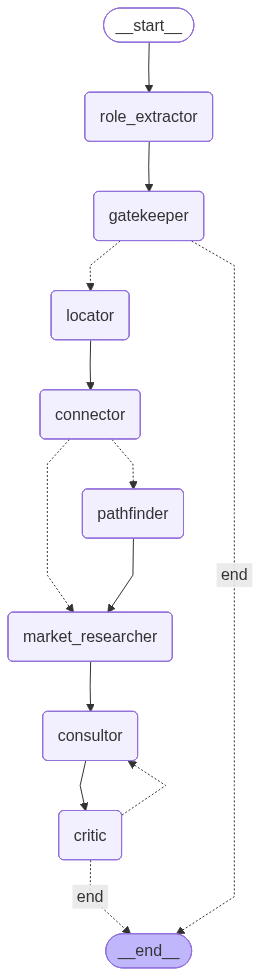

In [21]:
from IPython.display import Image, display

# Display the beautiful LangGraph architecture you just built
try:
    print("🎨 Generating LangGraph Architecture Map...")
    display(Image(talent_app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"⚠️ Could not generate image: {e}")
    # Fallback to an ASCII text graph if the image API is blocked
    print(talent_app.get_graph().draw_ascii())

In [23]:
print(vector_cypher_retriever("27-3043.00"))

{'title': 'Writers and Authors', 'skills': [{'level': 4.12, 'name': 'Reading Comprehension'}, {'level': 3.75, 'name': 'Active Listening'}, {'level': 5.12, 'name': 'Writing'}, {'level': 3.75, 'name': 'Speaking'}, {'level': 0.5, 'name': 'Mathematics'}, {'level': 0.12, 'name': 'Science'}, {'level': 4.0, 'name': 'Critical Thinking'}, {'level': 3.25, 'name': 'Active Learning'}, {'level': 2.88, 'name': 'Learning Strategies'}, {'level': 3.0, 'name': 'Monitoring'}], 'tasks': ["Develop advertising campaigns for a wide range of clients, working with an advertising agency's creative director and art director to determine the best way to present advertising information.", 'Vary language and tone of messages based on product and medium.', 'Present drafts and ideas to clients.', 'Discuss with the client the product, advertising themes and methods, and any changes that should be made in advertising copy.', 'Review advertising trends, consumer surveys, and other data regarding marketing of goods and s